# Prophet - Walmart Store Sales Forecasting

Person B track, fourth and last of four deliverables (DLinear, N-BEATS, TFT,
Prophet). Structurally different from the three darts models: **Prophet has
no global/panel training mode** - it always fits one model per series, so
this notebook cannot reuse the DLinear/N-BEATS/TFT harness directly.

Structure:
- Theory section on Prophet's additive decomposition, and the **scope
  decision** - which is the whole story of this notebook. An earlier revision
  fit one Prophet per *Store* (45 series) and split each store's forecast
  across departments by a constant historical share. That design cannot
  represent department-level seasonality at all, and it scored ~4,700 WMAE on
  Kaggle. This revision fits one Prophet per **(Store, Dept)** series (~3,300),
  which is what makes per-department seasonality and per-department holiday
  effects possible.
- A **`TESTLIKE` validation fold** - a structural replica of the real 39-week
  test horizon, containing Thanksgiving, Christmas and the Super Bowl. Every
  fold in the shared CV grid ends inside train and therefore cannot contain a
  Thanksgiving or Christmas week, which is how the previous revision came to
  report 2,901 WMAE on its holdout while scoring 4,680 on the leaderboard.
  All modelling decisions here are made on `TESTLIKE`.
- The **Christmas week-alignment fix**: weeks end on a Friday, so the week the
  competition marks as Christmas contains 0 pre-Christmas shopping days in
  2010, 1 in 2011, and 3 in 2012 - and 2012 is the one in test. An on/off
  holiday dummy therefore has to underpredict test's biggest, 5x-weighted
  week. Two day-count regressors replace it.
- Diagnostics on the company-level aggregate (with Prophet's own
  trend/seasonality/holiday component plot) and the same 3 representative
  high-volume `(Store, Dept)` series the ARIMA notebook uses, for direct
  comparability.
- 3-fold expanding-window CV on the aggregate series (same shared splits as
  every other model), one MLflow run per fold.
- A config A/B on `TESTLIKE`, then the winning per-(Store, Dept) panel refit on
  the full history and written out as a full-coverage Kaggle submission via
  `src.prophet_forecaster.ProphetPanelPipeline`.

Reuses `src/preprocessing.py` (`load_raw_data`), `src/features.py`
(`add_temporal_features`, `HOLIDAY_DATES`), `src/validation.py` (shared CV
splitter), and `src/evaluation.py` (`weighted_mae`). Logs to the shared
DagsHub MLflow server under the `Prophet_Training` experiment.

##  Init cell (Colab-compatible)

Byte-identical to the DLinear/N-BEATS/TFT notebooks' init cell (Person B's
track), minus the `darts[torch]` install those need and this notebook
doesn't - `prophet` is already covered by `requirements.txt`.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

IS_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

if IS_COLAB:
    REPO_URL = "https://github.com/NikaMikeltadze/walmart-sales-forecasting.git"
    REPO_DIR = "/content/walmart-sales-forecasting"

    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r",
         f"{REPO_DIR}/requirements.txt", "--quiet"],
        check=True,
    )

    os.chdir(f"{REPO_DIR}/notebooks")

    from google.colab import drive
    drive.mount("/content/drive")

    drive_data_dir = Path("/content/drive/MyDrive/walmart-sales-forecasting/data/raw")
    repo_data_dir = Path(REPO_DIR) / "data" / "raw"
    if drive_data_dir.exists():
        subprocess.run(["cp", "-r", f"{drive_data_dir}/.", str(repo_data_dir)], check=True)
    else:
        raise FileNotFoundError(
            f"Expected Drive data folder not found at {drive_data_dir}. "
            "Create it (or add it as a My Drive shortcut) before running this notebook."
        )

sys.path.append(str(Path.cwd().parent))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  Imports

In [ ]:
import logging
import warnings

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from prophet import Prophet

from src.evaluation import weighted_mae
from src.features import HOLIDAY_DATES, add_temporal_features
from src.preprocessing import load_raw_data
from src.prophet_forecaster import (
    MIN_OBS_FOR_PROPHET,
    ProphetConfig,
    ProphetPanelPipeline,
    add_xmas_regressors,
    build_walmart_holidays,
    compute_fallback_stats,
    fit_series_models,
)
from src.validation import Split, describe_split, expanding_window_splits, split_frame

warnings.filterwarnings("ignore")  # pmdarima-style convergence/deprecation chatter
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)  # silence per-chain fit spam
logging.getLogger("prophet").setLevel(logging.WARNING)
pd.set_option("display.max_columns", None)

DATA_DIR = Path.cwd().parent / "data" / "raw"
SUBMISSIONS_DIR = Path.cwd().parent / "submissions"
SUBMISSIONS_DIR.mkdir(exist_ok=True)

###  Manual credentials override (VS Code / non-Colab-UI runtimes)

`google.colab.userdata` (Colab Secrets) can only be read from the Colab
**browser UI**. When the Colab runtime is driven from VS Code or any other
non-UI frontend it times out (`Secrets can only be fetched when running from
the Colab UI`). This cell sets the DagsHub creds directly instead, and the
credentials cell below skips `userdata` whenever these env vars are already set.

`getpass` is used so the token is never written into this committed notebook -
run the cell and paste the values when prompted. Leave a prompt blank to fall
through to Colab Secrets / `.env` below (e.g. when you *are* on the Colab UI).

In [3]:
import os
from getpass import getpass

# Only prompt for values not already set, so re-running cells doesn't re-ask.
# Leave a prompt blank to fall through to Colab Secrets / .env in the next cell.
if not os.environ.get("MLFLOW_TRACKING_USERNAME"):
    _user = getpass("DagsHub username (blank -> use Colab Secrets / .env): ").strip()
    if _user:
        os.environ["MLFLOW_TRACKING_USERNAME"] = _user
if not os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    _token = getpass("DagsHub token (blank -> use Colab Secrets / .env): ").strip()
    if _token:
        os.environ["MLFLOW_TRACKING_PASSWORD"] = _token

##  Load DagsHub credentials

`MLFLOW_TRACKING_USERNAME`/`MLFLOW_TRACKING_PASSWORD` are never hardcoded in
this notebook (it gets committed to the shared repo, so a hardcoded token
would leak).

- On the Colab UI: read from Colab secrets - add `DAGSHUB_USERNAME` and
  `DAGSHUB_TOKEN` via the key icon in the left sidebar, and enable
  "Notebook access" for both. Same approach as every other notebook.
- From VS Code / non-UI runtimes: use the manual-override cell above.
- Locally: falls back to a gitignored `.env` in the repo root.

In [4]:
if os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    # Already provided (e.g. by the manual-override cell above when driving the
    # Colab runtime from VS Code, where google.colab.userdata would time out).
    # Note: userdata.get(...) must NOT be evaluated in this case - it blocks for
    # ~minutes and raises when there is no Colab browser UI to answer it.
    creds_source = "pre-set environment variables"
elif IS_COLAB:
    from google.colab import userdata

    os.environ["MLFLOW_TRACKING_USERNAME"] = userdata.get("DAGSHUB_USERNAME")
    os.environ["MLFLOW_TRACKING_PASSWORD"] = userdata.get("DAGSHUB_TOKEN")
    creds_source = "Colab secrets (DAGSHUB_USERNAME / DAGSHUB_TOKEN)"
else:
    from dotenv import load_dotenv

    env_path = Path.cwd().parent / ".env"
    load_dotenv(env_path)
    creds_source = str(env_path)

assert os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"), (
    f"MLFLOW_TRACKING_USERNAME/PASSWORD not set (tried: {creds_source}). "
    "On the Colab UI: add DAGSHUB_USERNAME and DAGSHUB_TOKEN as Colab secrets "
    "(key icon in the left sidebar) and enable notebook access for both. "
    "From VS Code / non-UI runtimes: run the manual-override cell above. "
    "Locally: create a .env in the repo root with MLFLOW_TRACKING_USERNAME=... "
    "and MLFLOW_TRACKING_PASSWORD=..."
)
print("MLflow credentials loaded from:", creds_source)

MLflow credentials loaded from: pre-set environment variables


##  MLflow tracking store

Shared DagsHub MLflow server - the single source of truth for cross-model
WMAE comparison and the Model Registry, so all 7 models (both tracks) log
here rather than to a per-notebook local store. Does not silently fall back
to a local store if auth fails - that would desync Prophet's runs from the
rest of the team's.

In [5]:
MLFLOW_TRACKING_URI = "https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    mlflow.set_experiment("Prophet_Training")
    mlflow.MlflowClient().search_experiments(max_results=1)  # force a network round trip now
except Exception as e:
    raise RuntimeError(
        "Could not authenticate to the DagsHub MLflow server at "
        f"{MLFLOW_TRACKING_URI}. Set MLFLOW_TRACKING_USERNAME and "
        "MLFLOW_TRACKING_PASSWORD (a DagsHub access token) as environment "
        "variables, then re-run this cell. Not falling back to local "
        "./mlruns or sqlite - that would desync from Person A's XGBoost/"
        "LightGBM runs and the rest of the team's runs."
    ) from e

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("Prophet_Training").name)

MLflow tracking URI: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow
Active experiment: Prophet_Training


## Load raw data

In [6]:
raw = load_raw_data(DATA_DIR)
for name, df in raw.items():
    print(f"{name}: {df.shape}")

assert raw["train"].shape[0] == 421_570, "unexpected train row count - check data/raw"
assert raw["test"].shape[0] > 0
assert raw["stores"].shape[0] == 45

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)


## External regressors from features.csv: deliberately NOT used

An earlier revision fed Temperature/Fuel_Price/CPI/Unemployment/MarkDown1-5
into the Prophet fits. This one does not, for two reasons:

1. **The MarkDown columns are a trap on this horizon.** They are entirely
   NaN before 2011-11 and populated after, and the project convention fills
   the NaNs with 0.0 ("no promotion that week"). To a linear regressor that
   is not a promotion signal, it is a step function that switches on partway
   through the series. Over a 39-week extrapolation Prophet can happily
   attribute a chunk of the level to it and then carry that mistake the
   whole way out.
2. **They are all Store-level.** They carry no information that distinguishes
   one department from another, which is precisely the axis this notebook now
   models. Nine extra coefficients per fit, times ~3,300 fits, on 143-point
   series, buys overfitting rather than signal.

The calendar - yearly seasonality, the holidays frame, and the Christmas
day-count regressors below - is known exactly for every future date and does
all the work here.

## Prophet - theory and scope decision

**Prophet** (Meta/Facebook, Taylor & Letham 2017) is an additive
decomposable time-series model:

`y(t) = trend(t) + seasonality(t) + holidays(t) + regressors(t) + error(t)`

- **trend(t):** a piecewise-linear (or logistic, or flat) curve with
  automatically detected changepoints, so the growth rate itself can shift
  over time - unlike ARIMA's differencing-to-stationarity approach, Prophet
  models the trend directly and explicitly.
- **seasonality(t):** partial Fourier sums fit per seasonal period. Only
  **yearly** seasonality is meaningful here - the data is already
  weekly-aggregated, so there is no day-of-week or intra-day pattern for
  `weekly_seasonality`/`daily_seasonality` to capture, and both are disabled.
- **holidays(t):** a per-date step effect from a user-supplied `holidays`
  dataframe - this is where the project's Walmart holidays get encoded.
- **regressors(t):** extra linear terms (`add_regressor`) for covariates
  known ahead of time. The Christmas day-count regressors below are exactly
  this: computable from the calendar for any future date.
- Fit is MAP estimation (`mcmc_samples=0`, Prophet's default) via
  `cmdstanpy`, not full Bayesian sampling.

**Key structural difference from every other model in this project:**
Prophet has **no global/panel training mode** - it always fits one model per
series. The darts models (DLinear/N-BEATS/TFT) are global models trained
once across all ~3,000 `(Store, Dept)` series; XGBoost/LightGBM are single
models over a shared feature matrix. Prophet cannot do this - "training
Prophet" always means "fit N independent per-series models," and N is a
modelling decision, not just a cost decision.

### The scope decision, and why the previous one was wrong

The first version of this notebook chose **N = 45 stores**, and recovered
`(Store, Dept)` rows by scaling each store's forecast by that department's
constant historical share of the store's total. The stated reason was time
budget: ~3,000 per-series fits looked too expensive.

That choice is what capped the score at **~4,700 WMAE on Kaggle**, and it is
worth being precise about why. If a department's forecast is
`store_forecast(t) x share(store, dept)` and the share is a *scalar*, then
inside a given store **every department has the identical seasonal curve**,
merely rescaled. Departments emphatically do not behave that way:
electronics roughly triples in the pre-Christmas week, grocery barely moves,
lawn/garden peaks in spring. A scalar share plus a single on/off holiday
multiplier cannot express any of it.

The Kaggle test horizon (2012-11-02 to 2013-07-26) consists almost entirely
of what that design could not represent: Thanksgiving and Christmas (which
WMAE weights **5x**) plus a full spring season. Meanwhile the shared
`HOLDOUT` fold (2012-08-03 to 2012-10-26) contains **neither a holiday nor a
spring**, so it reported a comfortable ~2,900 and never saw the failure. The
validation split was hiding the defect - see the test-like fold added below,
which fixes that.

**This revision chooses N = one model per (Store, Dept) series** (~3,300),
so seasonality and holiday coefficients are learned *per department*. The
cost objection turns out not to survive contact with the profiler: a MAP fit
on 143 weekly points with `uncertainty_samples=0` (Prophet otherwise draws
1,000 posterior samples per `predict()` call purely to populate
`yhat_lower`/`yhat_upper`, which nothing here reads) takes a fraction of a
second, and the fits are embarrassingly parallel across cores. Series with
under `MIN_OBS_FOR_PROPHET` weeks of history - too short for a yearly
seasonality to even be identifiable - fall back to a department-level
seasonal profile scaled to that series' own level, so *even the fallback
path now carries department seasonality*.

## Build the series to model

These two are for the **diagnostic** runs only - the theory exhibits that
mirror the ARIMA notebook. The series the submission is actually built from
are the ~3,300 per-`(Store, Dept)` ones, constructed inside
`src.prophet_forecaster.fit_series_models` further down.

- **Company aggregate:** total weekly sales summed across all stores/depts -
  used for the feature-selection, component-plot and CV runs below.
- **Representative series:** the same 3 highest-volume `(Store, Dept)` series
  (with full-length history) that the ARIMA notebook uses, so Prophet's
  per-series WMAE is directly comparable across the two classical-model
  notebooks.

A week is treated as a holiday week if any row that week is flagged
`IsHoliday` (WMAE weights holiday weeks 5x) - same convention as ARIMA.

In [8]:
train = raw["train"].copy()
train["Date"] = pd.to_datetime(train["Date"])

# Company-level weekly total sales (single aggregate series).
agg = train.groupby("Date")["Weekly_Sales"].sum().sort_index()

# Per-week holiday flag, shared by the aggregate scoring below.
holiday_by_date = train.groupby("Date")["IsHoliday"].any()

# 3 representative high-volume (Store, Dept) series with full-length history -
# same selection logic as the ARIMA notebook, for direct comparability.
series_len = train.groupby(["Store", "Dept"])["Date"].nunique()
full_len = series_len.max()
eligible = series_len[series_len == full_len].index
series_means = train.groupby(["Store", "Dept"])["Weekly_Sales"].mean()
rep_keys = series_means.loc[eligible].sort_values(ascending=False).head(3).index.tolist()
rep_keys = [(int(s), int(d)) for s, d in rep_keys]


def build_series(store, dept):
    """Return (values Series, holiday Series) both indexed by Date for one series."""
    g = train[(train["Store"] == store) & (train["Dept"] == dept)].sort_values("Date")
    values = g.set_index("Date")["Weekly_Sales"]
    values = values[~values.index.duplicated(keep="last")]
    holiday = g.groupby("Date")["IsHoliday"].any().reindex(values.index).fillna(False)
    return values, holiday


print("Aggregate series:", agg.shape[0], "weeks,",
      agg.index.min().date(), "->", agg.index.max().date())
print("Representative (Store, Dept) series:", rep_keys)
agg.tail(3)

Aggregate series: 143 weeks, 2010-02-05 -> 2012-10-26
Representative (Store, Dept) series: [(14, 92), (2, 92), (20, 92)]


,Weekly_Sales
Date,
2012-10-12,46128514.25
2012-10-19,45122410.57
2012-10-26,45544116.29


## Walmart holidays, and the Christmas week-alignment problem

Prophet's `holidays` parameter takes a dataframe of `(ds, holiday)` step
events. The Super Bowl, Labor Day and Thanksgiving dates in
`src.features.HOLIDAY_DATES` are already the Friday week-ending dates this
dataset uses, so they land exactly on the weekly `ds` grid - no window
guessing needed.

**Christmas does not behave, and the reason is arithmetic.** Weeks end on a
Friday and cover the 7 days `[ds-6, ds]`. Christmas Day drifts through the
week from year to year, so the number of *pre-Christmas shopping days* that
land inside the week the competition **marks** as the Christmas holiday is
not constant:

| marked week | days it covers | days of the Dec 15-24 rush inside it |
|---|---|---|
| 2010-12-31 | Dec 25-31 | **0** |
| 2011-12-30 | Dec 24-30 | **1** (Dec 24) |
| **2012-12-28** (in test) | Dec 22-28 | **3** (Dec 22, 23, 24) |

The two Christmas weeks a model can learn from contain almost none of the
Christmas rush. The one it has to *predict* contains three days of it. Any
on/off holiday dummy - which is the only thing a `holidays` dataframe can
express - will therefore **systematically underpredict test's single biggest
week**, and WMAE weights that week 5x. The previous revision's synthetic
`christmas_peak_week51` event does not fix this: it correctly points at where
the peak was in 2010 and 2011, but it still assumes 2012's marked week looks
like theirs, and it does not.

The fix (`src.prophet_forecaster.add_xmas_regressors`) is to stop counting
weeks and start counting **days**: two continuous regressors giving, for each
week, how many of its days fall in the pre-Christmas rush (Dec 15-24) and how
many fall after Christmas (Dec 26-31, returns and gift-card redemption).
Prophet fits a per-*day* coefficient, which extrapolates to 2012 correctly
instead of assuming every Christmas week is shaped like the training ones.
Note this leaves the week-51 peak weeks (2010-12-24, 2011-12-23, 2012-12-21)
untouched - each contains a full 7 rush days in every year, so they were
never the problem.

`build_walmart_holidays(include_christmas_dummies=...)` builds either
encoding, and the config A/B below settles which one actually wins. The two
must never be fit together: they are collinear.

In [ ]:
# Old encoding: Christmas as two on/off dummy events (the marked week plus a
# synthetic week-51 peak). Used by the diagnostic runs further down, and by
# the "xmas_dummies" arm of the config A/B, so the two encodings can be
# compared head to head.
WALMART_HOLIDAYS = build_walmart_holidays(include_christmas_dummies=True)

# New encoding: Christmas left out of the holidays frame entirely and carried
# by the two day-count regressors instead.
PANEL_HOLIDAYS = build_walmart_holidays(include_christmas_dummies=False)

print("with christmas dummies:", sorted(WALMART_HOLIDAYS["holiday"].unique()))
print("without (day-count regressors carry it):", sorted(PANEL_HOLIDAYS["holiday"].unique()))

# The whole argument, on the actual dates. `xmas_pre_days` is what a week-level
# dummy cannot see: the marked Christmas week goes 0 -> 1 -> 3 rush days across
# 2010/2011/2012, so a coefficient learned on the first two underpredicts 2012.
_xmas_demo_dates = pd.to_datetime([
    "2010-12-24", "2010-12-31",   # peak week, marked week
    "2011-12-23", "2011-12-30",
    "2012-12-21", "2012-12-28",   # 2012-12-28 is the week in test
])
_demo = add_xmas_regressors(_xmas_demo_dates)
_demo["marked_christmas_week"] = _demo.index.isin(
    pd.to_datetime([v for v in HOLIDAY_DATES["christmas"].values()])
)
_demo

## Time-based validation window

Uses the shared `expanding_window_splits` (same splitter as all other
models) so WMAE is comparable. The last fold is used as the reported
holdout.

**Known limitation (same as the tree models and ARIMA):** train ends
2012-11-01, so no validation fold can contain a Thanksgiving or Christmas
week - those only appear in the real `test.csv` horizon. WMAE weights
holiday weeks 5x and those are the two biggest sales holidays, so holdout
WMAE is optimistic relative to the true 39-week horizon.

In [10]:
splits = expanding_window_splits(pd.Series(agg.index), n_splits=3, val_weeks=13)
print(f"{len(splits)} folds")
for i, split in enumerate(splits):
    print(f"fold {i}:", describe_split(split))

HOLDOUT = splits[-1]
print("\nReported holdout:", describe_split(HOLDOUT))

3 folds
fold 0: {'train_start': 'start_of_history', 'train_end': '2012-01-27 00:00:00', 'val_start': '2012-02-03 00:00:00', 'val_end': '2012-04-27 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 1}
fold 1: {'train_start': 'start_of_history', 'train_end': '2012-04-27 00:00:00', 'val_start': '2012-05-04 00:00:00', 'val_end': '2012-07-27 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 0}
fold 2: {'train_start': 'start_of_history', 'train_end': '2012-07-27 00:00:00', 'val_start': '2012-08-03 00:00:00', 'val_end': '2012-10-26 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 1}

Reported holdout: {'train_start': 'start_of_history', 'train_end': '2012-07-27 00:00:00', 'val_start': '2012-08-03 00:00:00', 'val_end': '2012-10-26 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 1}


## The test-like fold: a validation window that can actually see the failure

Every fold above ends inside train, which ends 2012-11-01. **No expanding
-window fold built that way can contain a Thanksgiving or a Christmas week** -
the notebook already flagged this as a "known limitation," but it is worse
than a limitation, it is a validation split that cannot observe the two weeks
the score mostly depends on. The previous revision scored **2,901 WMAE** on
`HOLDOUT` and **4,680 on Kaggle**. That is not noise; the fold was measuring a
different problem.

So this section adds one more fold, chosen to be a **structural replica of the
real test set** rather than a continuation of the CV grid:

|  | train | horizon | holidays in horizon |
|---|---|---|---|
| Kaggle test | to 2012-10-26 | 2012-11-02 to 2013-07-26 (39w) | Thanksgiving, Christmas, Super Bowl |
| `TESTLIKE` | to 2011-11-04 | 2011-11-11 to 2012-08-03 (39w) | Thanksgiving, Christmas, Super Bowl |

Same horizon length, same three holidays, same position in the calendar year -
shifted back exactly one year. It costs a year of training history (92 weeks
instead of 143), which makes its absolute WMAE somewhat *pessimistic* relative
to the real submission. That is the right direction to be wrong in, and far
more useful than an optimistic number.

`HOLDOUT` is still reported at the end, unchanged, because the other six models
report it and cross-model comparability matters. But **every modelling decision
below is made on `TESTLIKE`**, because it is the only fold here that tracks the
leaderboard.

In [ ]:
# The real test horizon, for reference: 39 weeks starting the week after train ends.
TEST_WEEKS = raw["test"]["Date"].nunique()
print(f"Kaggle test: {TEST_WEEKS} weeks, "
      f"{raw['test']['Date'].min().date()} -> {raw['test']['Date'].max().date()}")

# Same shape, shifted back one year, so it lands inside train.
TESTLIKE = Split(
    train_end=pd.Timestamp("2011-11-04"),
    val_start=pd.Timestamp("2011-11-11"),
    val_end=pd.Timestamp("2012-08-03"),
)
print("TESTLIKE fold:", describe_split(TESTLIKE))

train_tl, val_tl = split_frame(train, TESTLIKE)
print(f"\ntrain: {train_tl['Date'].nunique()} weeks, {len(train_tl):,} rows")
print(f"val:   {val_tl['Date'].nunique()} weeks, {len(val_tl):,} rows")

# The point of the whole fold: it contains the weeks HOLDOUT cannot.
_val_holidays = sorted(val_tl.loc[val_tl["IsHoliday"], "Date"].dt.date.unique())
print("holiday weeks inside the fold:", _val_holidays)
assert len(_val_holidays) == 3, "expected Thanksgiving, Christmas and Super Bowl in TESTLIKE"
assert val_tl["Date"].nunique() == TEST_WEEKS, "TESTLIKE horizon must match the test horizon"

## MLflow run helper

`log_prophet_run` fits a `Prophet` model on the train portion of a
Date-indexed series, forecasts the holdout window, scores WMAE + MAE, and
logs one flat MLflow run (params = regressors used / CV strategy; metrics =
WMAE, MAE; artifacts = a forecast-vs-actual plot, plus an optional
trend/seasonality/holidays component plot). Same flat-run +
`experiment_group` tag convention the other 6 notebooks use.

In [ ]:
def _slice(series, split):
    train_s = series[series.index <= split.train_end]
    if split.train_start is not None:
        train_s = train_s[train_s.index >= split.train_start]
    val_s = series[(series.index >= split.val_start) & (series.index <= split.val_end)]
    return train_s, val_s


def log_prophet_run(run_name, experiment_group, series, holiday_series, split,
                     holidays_df, regressor_cols=None, extra_params=None,
                     extra_artifacts=None, log_components=False):
    """Fit Prophet on the split's train window, score the val window, log one run.

    This is the DIAGNOSTIC harness - it fits a single Prophet to one
    Date-indexed series (the company aggregate, or one representative
    (Store, Dept)). The submission is not built this way; see
    `fit_panel` further down.
    """
    train_s, val_s = _slice(series, split)
    regressor_cols = regressor_cols or []

    regressor_frame = None
    if regressor_cols:
        regressor_frame = add_temporal_features(
            pd.DataFrame({"Date": series.index})
        ).set_index("Date")

    train_df = pd.DataFrame({"ds": train_s.index, "y": train_s.to_numpy()})
    for col in regressor_cols:
        train_df[col] = train_df["ds"].map(regressor_frame[col])

    model = Prophet(
        holidays=holidays_df,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        # The company aggregate is a large, strictly positive series whose
        # seasonal swings scale with its level, so multiplicative suits it. The
        # per-(Store, Dept) panel below defaults to ADDITIVE instead: many
        # individual series have a small (occasionally negative, via returns)
        # level, and multiplicative seasonality is unstable on those. See
        # ProphetConfig.
        seasonality_mode="multiplicative",
    )
    for col in regressor_cols:
        model.add_regressor(col)
    model.fit(train_df)

    future = pd.DataFrame({"ds": val_s.index})
    for col in regressor_cols:
        future[col] = future["ds"].map(regressor_frame[col])
    forecast = model.predict(future)
    preds = forecast["yhat"].to_numpy().clip(min=0.0)

    val_holiday = holiday_series.reindex(val_s.index).fillna(False).to_numpy()
    wmae = weighted_mae(val_s.to_numpy(), preds, val_holiday)
    mae = float(np.mean(np.abs(val_s.to_numpy() - preds)))
    # Same relative-scale reporting as ARIMA's log_arima_run: the aggregate is a
    # much larger absolute number than a single (Store, Dept) series, so WMAE as
    # a % of the series' own mean makes runs comparable at a glance.
    wmae_pct = wmae / float(train_s.mean())

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag("experiment_group", experiment_group)
        mlflow.log_param("model_family", "Prophet")
        mlflow.log_param("regressors", ",".join(regressor_cols) if regressor_cols else "none")
        mlflow.log_param("n_train_obs", int(len(train_s)))
        mlflow.log_param("series_mean_level", float(train_s.mean()))
        mlflow.log_param("cv_strategy", "expanding_window")
        mlflow.log_params(describe_split(split))
        if extra_params:
            mlflow.log_params(extra_params)

        mlflow.log_metric("wmae", wmae)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("wmae_pct_of_series_mean", wmae_pct)

        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(series.index, series.to_numpy(), color="0.6", label="history")
        ax.plot(val_s.index, val_s.to_numpy(), marker="o", label="actual (val)")
        ax.plot(val_s.index, preds, marker="x", label="forecast")
        ax.axvline(split.train_end, color="k", ls="--", lw=1)
        ax.set_title(f"{run_name}: Prophet WMAE={wmae:,.0f} ({wmae_pct:.1%} of mean level)")
        ax.legend()
        plt.tight_layout()
        plot_path = SUBMISSIONS_DIR / f"_prophet_forecast_{run_name}.png"
        fig.savefig(plot_path)
        plt.show()
        mlflow.log_artifact(str(plot_path))

        if log_components:
            full_frame = pd.concat([train_df, future], ignore_index=True)
            full_forecast = model.predict(full_frame)
            comp_fig = model.plot_components(full_forecast)
            comp_fig.set_size_inches(11, 8)
            plt.tight_layout()
            comp_path = SUBMISSIONS_DIR / f"_prophet_components_{run_name}.png"
            comp_fig.savefig(comp_path, bbox_inches="tight")
            plt.show()
            mlflow.log_artifact(str(comp_path))

        for art in (extra_artifacts or []):
            mlflow.log_artifact(str(art))

        run_id = run.info.run_id

    print(f"{run_name}: WMAE={wmae:,.2f} ({wmae_pct:.2%} of series mean) MAE={mae:,.2f}")
    return {"model": model, "wmae": wmae, "mae": mae, "wmae_pct": wmae_pct, "run_id": run_id}

## Feature selection: holidays-only baseline vs. added regressors

Two small runs on the company aggregate, scored on the shared `HOLDOUT`
fold, decide whether `days_to_christmas`/`days_to_thanksgiving` regressors
earn their keep on top of the custom holidays dataframe. Whichever wins gets
carried forward as `WINNING_REGRESSOR_COLS` into every later run (aggregate,
CV, representative series, and the final store-level submission strategy) -
this is the `{Model}_Feature_Selection` stage CLAUDE.md's MLflow convention
expects.

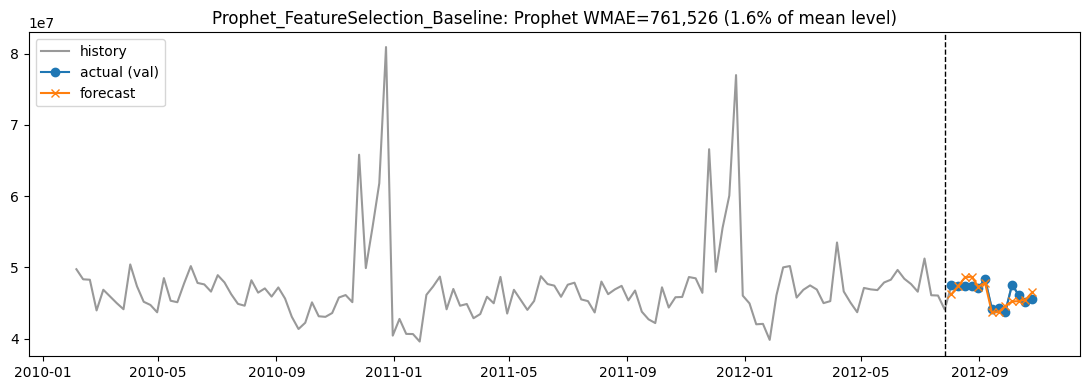

🏃 View run Prophet_FeatureSelection_Baseline at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/ce90d09c918a4054abebf306c8bf1eb7
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7
Prophet_FeatureSelection_Baseline: WMAE=761,525.93 (1.61% of series mean) MAE=840,996.00


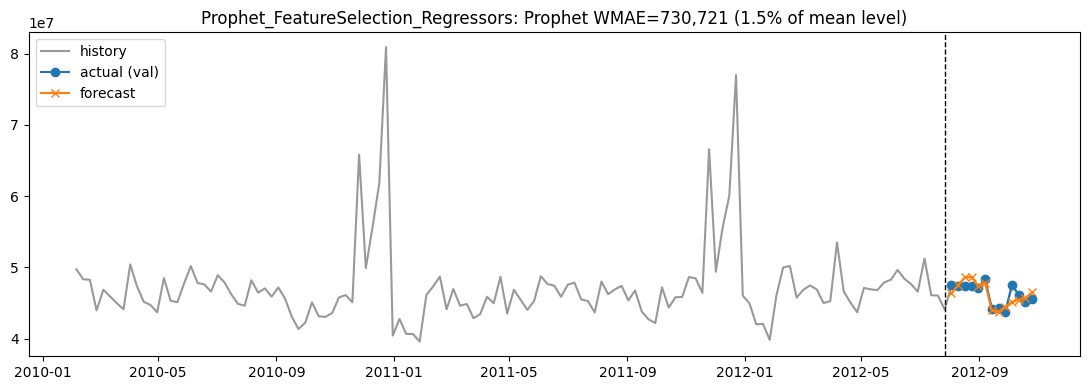

🏃 View run Prophet_FeatureSelection_Regressors at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/9c67c379c09f407f864b291b55d4c6af
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7
Prophet_FeatureSelection_Regressors: WMAE=730,720.62 (1.55% of series mean) MAE=813,671.00

Baseline WMAE:   761,525.93
Regressors WMAE: 730,720.62
Winning config: regressors


In [12]:
base_result = log_prophet_run(
    "Prophet_FeatureSelection_Baseline", "feature_selection", agg, holiday_by_date, HOLDOUT,
    WALMART_HOLIDAYS, regressor_cols=None,
    extra_params={"config": "holidays_only"},
)

CANDIDATE_REGRESSORS = ["days_to_christmas", "days_to_thanksgiving"]
reg_result = log_prophet_run(
    "Prophet_FeatureSelection_Regressors", "feature_selection", agg, holiday_by_date, HOLDOUT,
    WALMART_HOLIDAYS, regressor_cols=CANDIDATE_REGRESSORS,
    extra_params={"config": "holidays_plus_days_to_regressors"},
)

WINNING_REGRESSOR_COLS = CANDIDATE_REGRESSORS if reg_result["wmae"] < base_result["wmae"] else None
print(f"\nBaseline WMAE:   {base_result['wmae']:,.2f}")
print(f"Regressors WMAE: {reg_result['wmae']:,.2f}")
print(f"Winning config: {'regressors' if WINNING_REGRESSOR_COLS else 'baseline (holidays only)'}")

## Experiment: Prophet on the company aggregate

Full diagnostic run on the aggregate series, using the winning
feature-selection config. Also logs Prophet's own `plot_components` figure
(trend / yearly seasonality / holiday effects) - this is the Prophet-native
equivalent of ARIMA's ACF/PACF + seasonal-decomposition plots, and is the
clearest single artifact for checking that the `christmas_peak_week51`
event actually picked up a distinct, sensible coefficient.

**Reading the WMAE:** the aggregate is **summed** company sales (~$47M/week
on average), so its absolute WMAE is naturally far larger than the
per-series WMAE the tree models and the representative-series run below
report - a difference in scale, not model quality. `log_prophet_run` also
logs `wmae_pct_of_series_mean` for exactly this reason.

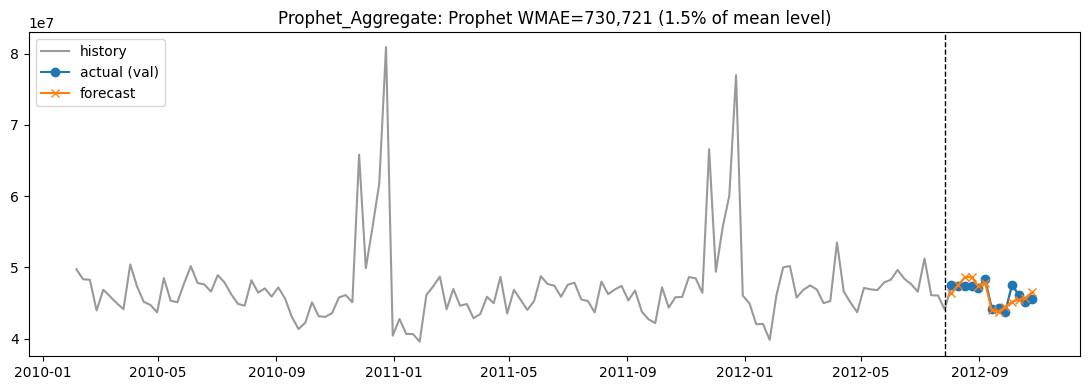

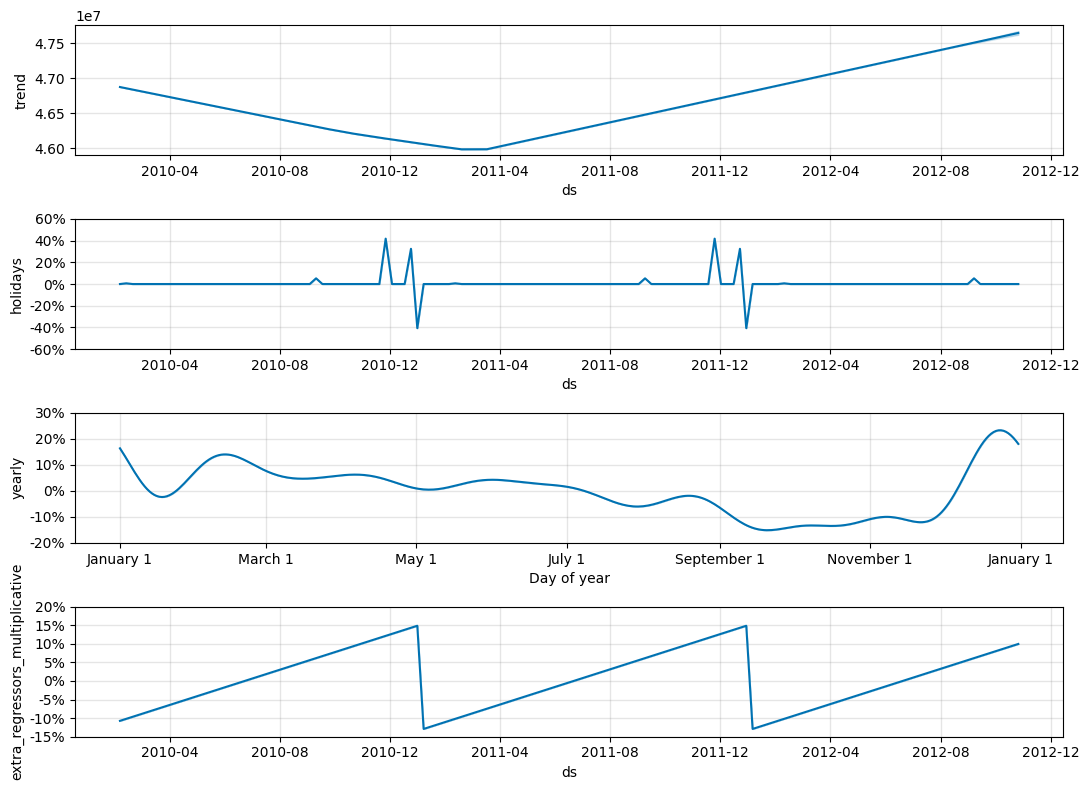

🏃 View run Prophet_Aggregate at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/1634e1a004944184810b03a27eb1e42e
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7
Prophet_Aggregate: WMAE=730,720.62 (1.55% of series mean) MAE=813,671.00


In [13]:
agg_result = log_prophet_run(
    "Prophet_Aggregate", "aggregate", agg, holiday_by_date, HOLDOUT,
    WALMART_HOLIDAYS, regressor_cols=WINNING_REGRESSOR_COLS,
    extra_params={"scope": "company_aggregate"},
    log_components=True,
)

## Cross-validation: 3 expanding-window folds

Same 3 folds built above (`splits`), on the aggregate series. Following the
TFT notebook's convention (rather than DLinear/N-BEATS's single-run style),
**each fold gets its own MLflow run** (`Prophet_CV_Fold0/1/2`) so per-fold
diagnostics (forecast plot, params) are individually browsable in the
DagsHub UI. A summary WMAE-by-fold bar chart is generated afterward and
attached to the last fold's run.

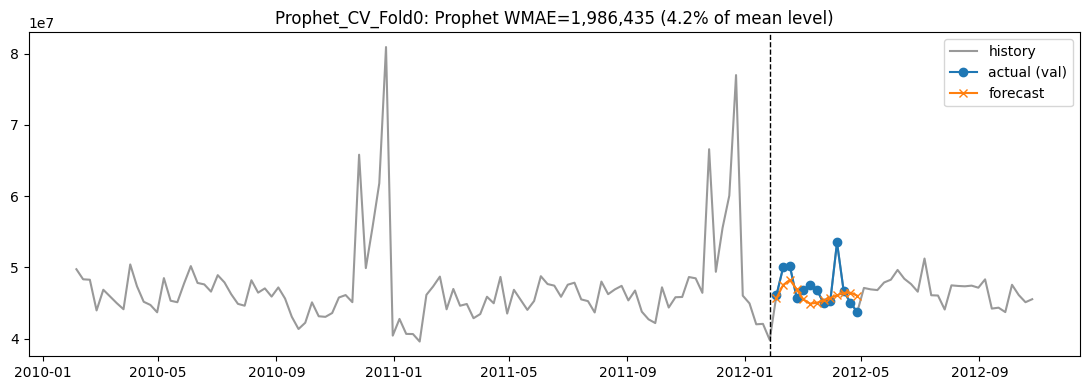

🏃 View run Prophet_CV_Fold0 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/07c85bf7241645f0a4d2d3a1567eb862
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7
Prophet_CV_Fold0: WMAE=1,986,434.62 (4.21% of series mean) MAE=1,836,405.99


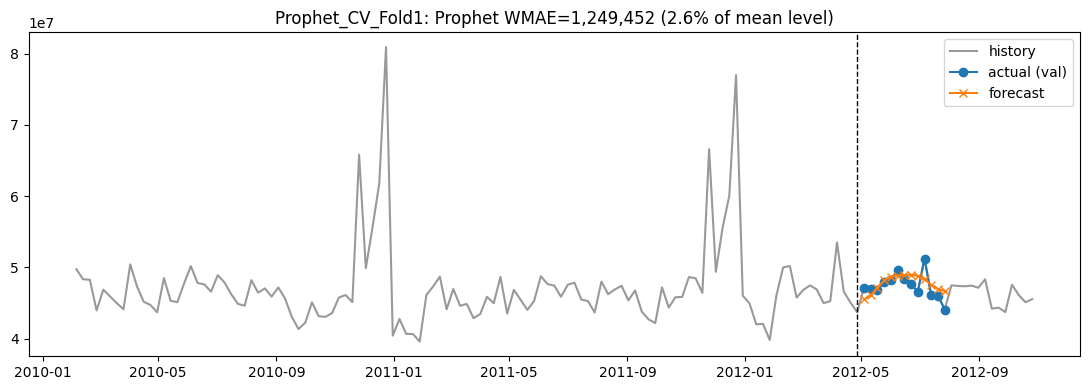

🏃 View run Prophet_CV_Fold1 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/c7446502983348ed9620044cce0d1ec1
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7
Prophet_CV_Fold1: WMAE=1,249,451.92 (2.65% of series mean) MAE=1,249,451.92


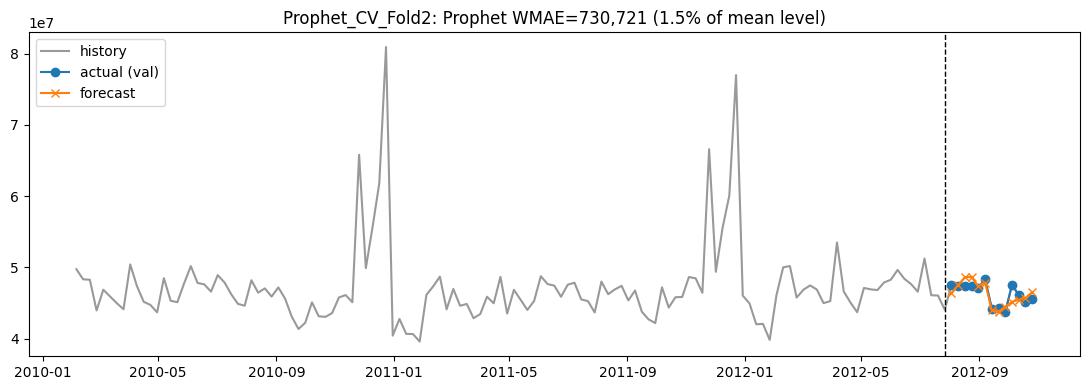

🏃 View run Prophet_CV_Fold2 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/089e11bae4bf484ca57429ef04dba549
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7
Prophet_CV_Fold2: WMAE=730,720.62 (1.55% of series mean) MAE=813,671.00

CV WMAE by fold: [np.float64(1986434.6), np.float64(1249451.9), np.float64(730720.6)]
Mean CV WMAE: 1,322,202.39 +/- 515,217.68


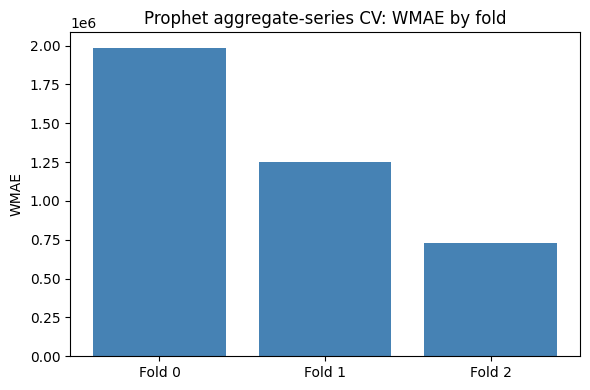

🏃 View run Prophet_CV_Fold2 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/089e11bae4bf484ca57429ef04dba549
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7


In [14]:
cv_results = []
for i, split in enumerate(splits):
    res = log_prophet_run(
        f"Prophet_CV_Fold{i}", "cv", agg, holiday_by_date, split,
        WALMART_HOLIDAYS, regressor_cols=WINNING_REGRESSOR_COLS,
        extra_params={"fold": i},
    )
    cv_results.append(res)

fold_wmaes = [r["wmae"] for r in cv_results]
print(f"\nCV WMAE by fold: {[round(w, 1) for w in fold_wmaes]}")
print(f"Mean CV WMAE: {np.mean(fold_wmaes):,.2f} +/- {np.std(fold_wmaes):,.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([f"Fold {i}" for i in range(len(fold_wmaes))], fold_wmaes, color="steelblue")
ax.set_ylabel("WMAE")
ax.set_title("Prophet aggregate-series CV: WMAE by fold")
plt.tight_layout()
CV_BAR_PATH = SUBMISSIONS_DIR / "_prophet_cv_wmae_by_fold.png"
fig.savefig(CV_BAR_PATH)
plt.show()

with mlflow.start_run(run_id=cv_results[-1]["run_id"]):
    mlflow.log_artifact(str(CV_BAR_PATH))

## Experiment: Prophet on representative high-volume series

Prophet on each of the same 3 representative `(Store, Dept)` series ARIMA
uses. These WMAE values are at the **same per-series scale** as the tree
models and ARIMA's `ARIMA_Series_*` runs, but note the same **limitation**
ARIMA states: scoped to only these 3 series (not all ~2,950), illustrative
of Prophet's per-series behavior rather than a full-panel score. The
full-panel number is the store-level + disaggregation strategy validated
below.

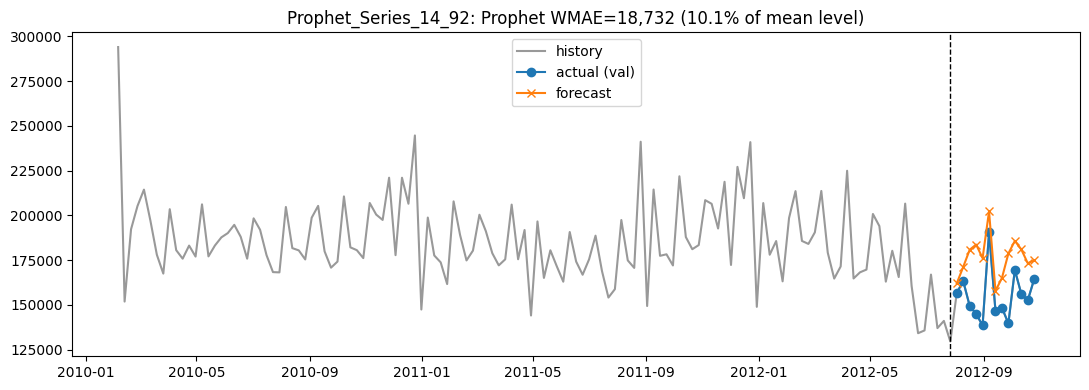

🏃 View run Prophet_Series_14_92 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/8dd6efcda67841f3b6a1ee2285a3cec1
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7
Prophet_Series_14_92: WMAE=18,731.87 (10.11% of series mean) MAE=20,906.19


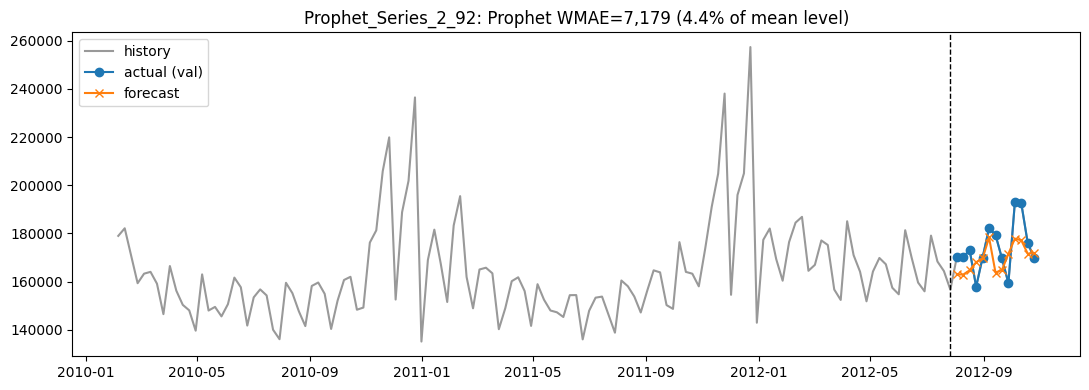

🏃 View run Prophet_Series_2_92 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/f60a6a7efea84783860a0411d62c3977
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7
Prophet_Series_2_92: WMAE=7,178.96 (4.38% of series mean) MAE=8,196.76


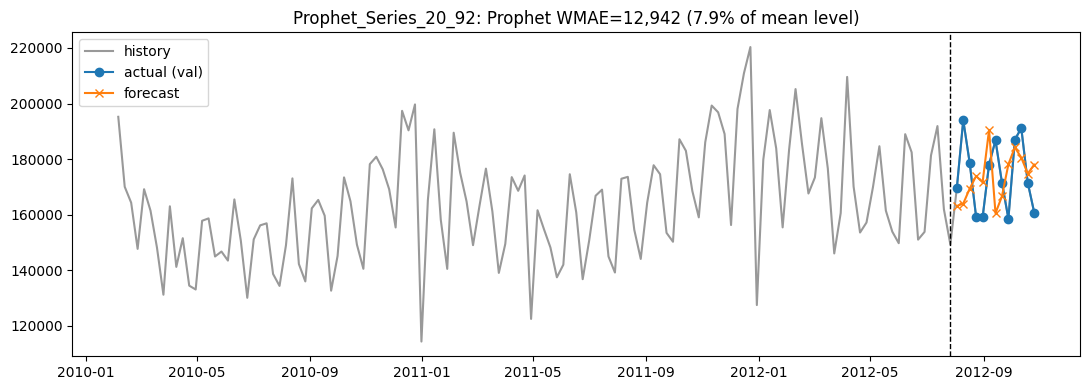

🏃 View run Prophet_Series_20_92 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/278c5333818149c8a328be153b84b85a
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7
Prophet_Series_20_92: WMAE=12,942.30 (7.91% of series mean) MAE=13,084.01

Mean WMAE across 3 representative series: 12,951.05


In [15]:
rep_results = []
for store, dept in rep_keys:
    values, holiday = build_series(store, dept)
    res = log_prophet_run(
        f"Prophet_Series_{store}_{dept}", "representative_series",
        values, holiday, HOLDOUT, WALMART_HOLIDAYS,
        regressor_cols=WINNING_REGRESSOR_COLS,
        extra_params={"store": store, "dept": dept, "scope": "single_series"},
    )
    rep_results.append(((store, dept), res))

rep_wmae_mean = float(np.mean([r["wmae"] for _, r in rep_results]))
print(f"\nMean WMAE across {len(rep_results)} representative series: {rep_wmae_mean:,.2f}")

## The actual submission strategy: a per-(Store, Dept) Prophet panel

The `Prophet_Aggregate` / `Prophet_Series_*` / `Prophet_CV_*` runs above are
theory and diagnostic exhibits on the aggregate series or a handful of
individual ones. They are **not** the strategy that ships, and their WMAE
values are not comparable to it (different unit scale for the aggregate, only
3 series for the representative runs).

What ships is `src.prophet_forecaster.ProphetPanelPipeline`: **one Prophet
model per (Store, Dept) series**, each learning its own yearly seasonality,
its own holiday coefficients, and its own Christmas day-count response.
Series with under `MIN_OBS_FOR_PROPHET` weeks of history, and pairs that show
up in test but never in train, fall back to a department-level week-of-year
seasonal profile scaled to that series' own level.

### Config selection

Four configurations, each isolating one decision, scored on `TESTLIKE`. To
keep this affordable they are compared on a **random sample of series** rather
than the full panel four times over - the ranking is what matters here, and
the winner is then refit on the full panel below.

| config | question it answers |
|---|---|
| `flat_additive_xmasdays` | the proposed default |
| `linear_damped_xmasdays` | is a (damped) trend worth having, or does 39 weeks of extrapolation from 92 noisy points just drift? |
| `flat_additive_xmasdummies` | do the Christmas day-count regressors actually beat the old on/off dummies? |
| `flat_multiplicative_xmasdays` | do seasonal swings scale with a series' level, or add to it? |

Note that `growth="flat"` is not a lazy choice. It removes the trend term
entirely, leaving level + seasonality + holidays. On a 143-point series with a
39-week extrapolation, a freely-hinging piecewise-linear trend is the single
easiest way to turn a good seasonal fit into a bad forecast, and it has no
mechanism to know it has gone wrong.

In [ ]:
def holidays_for(config: ProphetConfig) -> pd.DataFrame:
    """The holidays frame matching a config's Christmas encoding.

    The day-count regressors and the on/off Christmas dummies are collinear,
    so exactly one of them is ever in a given fit.
    """
    return build_walmart_holidays(include_christmas_dummies=not config.use_xmas_regressors)


def fit_panel(config, train_df, keys=None, n_jobs=-1, verbose=True) -> ProphetPanelPipeline:
    models = fit_series_models(
        train_df, holidays_for(config), config=config, keys=keys,
        n_jobs=n_jobs, verbose=verbose,
    )
    return ProphetPanelPipeline(
        series_models_json=models,
        fallback=compute_fallback_stats(train_df),
        config=config,
        n_jobs=n_jobs,
    )


def score_panel(pipeline, val_df):
    preds = pipeline.predict(val_df)
    y = val_df["Weekly_Sales"].to_numpy()
    is_holiday = val_df["IsHoliday"].to_numpy()
    wmae = weighted_mae(y, preds, is_holiday)
    mae = float(np.mean(np.abs(y - preds)))
    return preds, wmae, mae


# --- config A/B on a random sample of series, scored on TESTLIKE -------------
N_SAMPLE_SERIES = 300
rng = np.random.default_rng(42)

_counts = train_tl.groupby(["Store", "Dept"]).size()
eligible_keys = [(int(s), int(d)) for s, d in _counts[_counts >= MIN_OBS_FOR_PROPHET].index]
sample_keys = [
    eligible_keys[i]
    for i in rng.choice(len(eligible_keys), size=min(N_SAMPLE_SERIES, len(eligible_keys)),
                        replace=False)
]
sample_set = set(sample_keys)
val_sample = val_tl[
    [(int(s), int(d)) in sample_set for s, d in zip(val_tl["Store"], val_tl["Dept"])]
].copy()

print(f"{len(eligible_keys)} series have >= {MIN_OBS_FOR_PROPHET} weeks of history in the "
      f"TESTLIKE train window.")
print(f"A/B on a random {len(sample_keys)} of them ({len(val_sample):,} validation rows).\n")

CANDIDATE_CONFIGS = {
    "flat_additive_xmasdays": ProphetConfig(),
    "linear_damped_xmasdays": ProphetConfig(growth="linear", changepoint_prior_scale=0.01),
    "flat_additive_xmasdummies": ProphetConfig(use_xmas_regressors=False),
    "flat_multiplicative_xmasdays": ProphetConfig(seasonality_mode="multiplicative"),
}

ab_results = {}
for name, cfg in CANDIDATE_CONFIGS.items():
    pipe = fit_panel(cfg, train_tl, keys=sample_keys, verbose=False)
    _, wmae, mae = score_panel(pipe, val_sample)
    ab_results[name] = wmae

    with mlflow.start_run(run_name=f"Prophet_PanelConfig_{name}"):
        mlflow.set_tag("experiment_group", "panel_config_selection")
        mlflow.log_param("model_family", "Prophet")
        mlflow.log_param("scope", "per_store_dept_panel")
        mlflow.log_param("config_name", name)
        mlflow.log_param("n_sample_series", len(sample_keys))
        mlflow.log_param("fold", "TESTLIKE")
        mlflow.log_params(cfg.as_mlflow_params())
        mlflow.log_params(describe_split(TESTLIKE))
        mlflow.log_metric("wmae", wmae)
        mlflow.log_metric("mae", mae)

    print(f"{name:30s} WMAE={wmae:9,.2f}   MAE={mae:9,.2f}")

BEST_CONFIG_NAME = min(ab_results, key=ab_results.get)
BEST_CONFIG = CANDIDATE_CONFIGS[BEST_CONFIG_NAME]
print(f"\nWinner on TESTLIKE: {BEST_CONFIG_NAME}  (WMAE {ab_results[BEST_CONFIG_NAME]:,.2f})")
print(BEST_CONFIG)

### Full-panel score on TESTLIKE

The winning config, refit on **every** eligible series in the `TESTLIKE` train
window and scored across all `(Store, Dept)` rows of the 39-week horizon. This
is the number that should be believed: same horizon length, same three
holidays, same scoring metric as the leaderboard, on a fold the model has
never seen.

The per-week WMAE plot below is the diagnostic that the old design never had.
Holiday weeks are marked; if the model is still mispricing Christmas, it will
be obvious as a spike there rather than being averaged away into a single
summary number.

In [ ]:
panel_tl = fit_panel(BEST_CONFIG, train_tl, n_jobs=-1, verbose=True)
tl_preds, TESTLIKE_WMAE, TESTLIKE_MAE = score_panel(panel_tl, val_tl)
tl_coverage = panel_tl.coverage(val_tl)

print(f"\nTESTLIKE full-panel WMAE: {TESTLIKE_WMAE:,.2f}   MAE: {TESTLIKE_MAE:,.2f}")
print(f"coverage: {tl_coverage['prophet_row_fraction']:.1%} of rows from a fitted Prophet "
      f"model, {tl_coverage['n_fallback_rows']:,} rows from the fallback")

# Per-week error, holiday weeks marked. Christmas is the week to watch.
_wk = val_tl[["Date", "Weekly_Sales", "IsHoliday"]].copy()
_wk["abs_err"] = np.abs(val_tl["Weekly_Sales"].to_numpy() - tl_preds)
by_week = _wk.groupby("Date").agg(mae=("abs_err", "mean"), is_holiday=("IsHoliday", "any"))

fig, ax = plt.subplots(figsize=(12, 4))
colors = ["crimson" if h else "steelblue" for h in by_week["is_holiday"]]
ax.bar(by_week.index, by_week["mae"], width=5, color=colors)
ax.set_ylabel("mean absolute error")
ax.set_title(
    f"Prophet panel, TESTLIKE horizon: MAE by week "
    f"(red = holiday week, weighted 5x)   |   WMAE = {TESTLIKE_WMAE:,.0f}"
)
plt.tight_layout()
TL_PLOT_PATH = SUBMISSIONS_DIR / "_prophet_panel_testlike_mae_by_week.png"
fig.savefig(TL_PLOT_PATH)
plt.show()

with mlflow.start_run(run_name="Prophet_Panel_TestLikeValidation"):
    mlflow.set_tag("experiment_group", "final_validation")
    mlflow.log_param("model_family", "Prophet")
    mlflow.log_param("strategy", "per_store_dept_prophet_panel")
    mlflow.log_param("config_name", BEST_CONFIG_NAME)
    mlflow.log_param("fold", "TESTLIKE")
    mlflow.log_params(BEST_CONFIG.as_mlflow_params())
    mlflow.log_params(describe_split(TESTLIKE))
    mlflow.log_params({f"coverage_{k}": v for k, v in tl_coverage.items()})
    mlflow.log_metric("wmae", TESTLIKE_WMAE)
    mlflow.log_metric("mae", TESTLIKE_MAE)
    mlflow.log_artifact(str(TL_PLOT_PATH))

### The shared HOLDOUT fold, for cross-model comparability only

The other six models all report the shared `HOLDOUT` fold, so Prophet reports
it too and it stays the headline metric on `Prophet_Final`. Read it as a
comparability number, **not** as a forecast of the Kaggle score: `HOLDOUT` is
13 weeks of Aug-Oct with one minor holiday (Labor Day) and no spring, so it
flatters any model that is bad at exactly the thing the test set is made of.
That is precisely how the previous revision came to report 2,901 here while
scoring 4,680 on the leaderboard.

`TESTLIKE` above is the number to trust.

In [ ]:
train_holdout, val_holdout = split_frame(train, HOLDOUT)

panel_holdout = fit_panel(BEST_CONFIG, train_holdout, n_jobs=-1, verbose=True)
_, HOLDOUT_WMAE, HOLDOUT_MAE = score_panel(panel_holdout, val_holdout)

with mlflow.start_run(run_name="Prophet_Panel_HoldoutValidation"):
    mlflow.set_tag("experiment_group", "final_validation")
    mlflow.log_param("model_family", "Prophet")
    mlflow.log_param("strategy", "per_store_dept_prophet_panel")
    mlflow.log_param("config_name", BEST_CONFIG_NAME)
    mlflow.log_param("fold", "HOLDOUT_shared")
    mlflow.log_params(BEST_CONFIG.as_mlflow_params())
    mlflow.log_params(describe_split(HOLDOUT))
    mlflow.log_metric("wmae", HOLDOUT_WMAE)
    mlflow.log_metric("mae", HOLDOUT_MAE)

print(f"\nShared HOLDOUT WMAE: {HOLDOUT_WMAE:,.2f}   MAE: {HOLDOUT_MAE:,.2f}")
print(f"TESTLIKE WMAE:       {TESTLIKE_WMAE:,.2f}   (the one that tracks Kaggle)")

## Final fit + full-coverage submission

The winning config, refit on the **full** train history (143 weeks, vs the 92
`TESTLIKE` had) and applied to the real 39-week test horizon. The extra year of
history is why the Kaggle score should come in a little better than
`TESTLIKE_WMAE`, not worse.

The fitted `ProphetPanelPipeline` is what gets `joblib.dump`'d and logged to
MLflow - it is the artifact `model_inference.ipynb` loads and calls
`.predict()` on raw `test.csv`-shaped data. It only needs `Store`, `Dept` and
`Date`: holiday effects now live inside the per-series Prophet models rather
than in a share lookup, and both the holidays frame and the Christmas
day-count regressors are derived from the date. Dumped with `compress=3`,
since ~3,300 serialized Prophet models are a few hundred MB raw.

In [ ]:
final_pipeline = fit_panel(BEST_CONFIG, train, n_jobs=-1, verbose=True)

test_coverage = final_pipeline.coverage(raw["test"])
print(f"\ntest coverage: {test_coverage['prophet_row_fraction']:.1%} of rows from a fitted "
      f"Prophet model ({test_coverage['n_series_fitted']:,} series), "
      f"{test_coverage['n_fallback_rows']:,} rows from the dept-seasonal fallback")

MODEL_PATH = SUBMISSIONS_DIR / "_prophet_forecaster.joblib"
joblib.dump(final_pipeline, MODEL_PATH, compress=3)
print(f"pipeline: {MODEL_PATH.stat().st_size / 1e6:.1f} MB on disk")

with mlflow.start_run(run_name="Prophet_Final") as final_run:
    mlflow.set_tag("experiment_group", "final")
    mlflow.log_param("model_family", "Prophet")
    mlflow.log_param("strategy", "per_store_dept_prophet_panel")
    mlflow.log_param("config_name", BEST_CONFIG_NAME)
    mlflow.log_params(BEST_CONFIG.as_mlflow_params())
    mlflow.log_param("n_series_fitted", len(final_pipeline.series_models_json))
    mlflow.log_param("min_obs_for_prophet", MIN_OBS_FOR_PROPHET)
    mlflow.log_params({f"coverage_{k}": v for k, v in test_coverage.items()})

    # Headline metric: the shared HOLDOUT fold, so this run lines up with the
    # other six models' reported WMAE.
    mlflow.log_metric("wmae", HOLDOUT_WMAE)
    mlflow.log_metric("mae", HOLDOUT_MAE)

    # The metric that actually predicts the Kaggle score - same 39-week horizon
    # and same three holidays as the real test set. Logged alongside because
    # HOLDOUT alone is what misled the previous revision by ~1,800 WMAE.
    mlflow.log_metric("wmae_testlike_39w", TESTLIKE_WMAE)
    mlflow.log_metric("mae_testlike_39w", TESTLIKE_MAE)

    # Reference-only metrics from the diagnostic runs above - different scope
    # and scale, NOT this model's own score. Prefixed so they can never be
    # mistaken for it.
    mlflow.log_metric("reference_prophet_aggregate_wmae", agg_result["wmae"])
    mlflow.log_metric("reference_prophet_representative_series_wmae_mean", rep_wmae_mean)

    mlflow.log_artifact(str(MODEL_PATH))
    final_run_id = final_run.info.run_id

print("\nLogged Prophet_Final, run_id:", final_run_id)
print(f"  headline WMAE (shared HOLDOUT):        {HOLDOUT_WMAE:,.2f}")
print(f"  WMAE on the test-like 39-week fold:    {TESTLIKE_WMAE:,.2f}  <- expect Kaggle near this")

## Submission

Runs the fitted pipeline directly on raw `test.csv`-shaped data and writes
`submissions/prophet_submission.csv` in the standard `Id` =
`Store_Dept_Date` format, then verifies it matches `sampleSubmission.csv`
row-for-row and attaches it to the `Prophet_Final` run.

In [18]:
test_preds = final_pipeline.predict(raw["test"])
assert not np.isnan(test_preds).any(), "pipeline produced NaN predictions on raw test data"

submission = pd.DataFrame(
    {
        "Id": (
            raw["test"]["Store"].astype(str)
            + "_"
            + raw["test"]["Dept"].astype(str)
            + "_"
            + raw["test"]["Date"].dt.strftime("%Y-%m-%d")
        ),
        "Weekly_Sales": test_preds,
    }
)

SUBMISSION_PATH = SUBMISSIONS_DIR / "prophet_submission.csv"
submission.to_csv(SUBMISSION_PATH, index=False)
print("Wrote", SUBMISSION_PATH, submission.shape)

# Hard integrity checks (do not depend on any other file).
assert submission.shape == (115064, 2), submission.shape
assert list(submission.columns) == ["Id", "Weekly_Sales"]
assert not submission["Weekly_Sales"].isna().any()

# Optional row-for-row cross-check against sampleSubmission. Wrapped so a locked
# file (e.g. open in Excel) does not break the run - the Id order is already
# guaranteed by construction (same raw test frame the other notebooks used).
try:
    sample = pd.read_csv(DATA_DIR / "sampleSubmission.csv")
    assert submission["Id"].tolist() == sample["Id"].tolist(), "Id order mismatch vs sampleSubmission"
    print("Submission matches sampleSubmission row-for-row:", submission.shape[0], "rows, no NaNs.")
except PermissionError:
    print("Note: sampleSubmission.csv is locked (open elsewhere) - skipped the row-for-row "
          "cross-check. Shape/column/NaN checks passed:", submission.shape)
submission.head()

Wrote /content/walmart-sales-forecasting/submissions/prophet_submission.csv (115064, 2)
Submission matches sampleSubmission row-for-row: 115064 rows, no NaNs.


,Id,Weekly_Sales
0,1_1_2012-11-02,23087.492571
1,1_1_2012-11-09,23574.343956
2,1_1_2012-11-16,23440.303711
3,1_1_2012-11-23,28656.388909
4,1_1_2012-11-30,22978.219098


In [19]:
with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact(str(SUBMISSION_PATH))

print("Submission logged as an artifact on Prophet_Final (run_id:", final_run_id, ")")

🏃 View run Prophet_Final at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/233e31979e3d4fbc88b6fc7638dbe2c3
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/7
Submission logged as an artifact on Prophet_Final (run_id: 233e31979e3d4fbc88b6fc7638dbe2c3 )
